## **Assignment 1: Generative Deep Learning - 708.088 (SS26)**
**Authored by:** Ozan Özdenizci, Institute of Machine Learning and Neural Computation, TU Graz

**Assignment issued on:** March 19th, 2026 09:00 AM\
**Assignment deadline:** April 16th, 2026 09:00 AM

# Training a VQ-VAE with an Autoregressive Prior

Vector-quantized variational autoencoders (VQ-VAE) combined with an autoregressive prior over the discrete latent space.


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F


torch.manual_seed(42)
np.random.seed(42)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1).float())
])

train_data = torchvision.datasets.MNIST(root='data/', train=True, transform=transform, download=True)
test_data = torchvision.datasets.MNIST(root='data/', train=False, transform=transform, download=True)

train_data, val_data = torch.utils.data.random_split(train_data, [55000, 5000])

training_loader = DataLoader(train_data, batch_size=128, shuffle=True)
val_loader = DataLoader(val_data, batch_size=128, shuffle=False)
test_loader = DataLoader(test_data, batch_size=128, shuffle=False)

### Part (a): VQ-VAE architecture

In [ ]:
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim, num_latents):
        super(Encoder, self).__init__()
        self.num_latents = num_latents
        self.latent_dim = latent_dim
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LeakyReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(),
            nn.Linear(hidden_dim, num_latents * latent_dim)
        )

    def forward(self, x):
        h = self.net(x)
        return h.reshape(x.shape[0], self.num_latents, self.latent_dim)


class Decoder(nn.Module):
    def __init__(self, latent_dim, num_latents, hidden_dim, output_dim):
        super(Decoder, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(num_latents * latent_dim, hidden_dim),
            nn.LeakyReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(),
            nn.Linear(hidden_dim, output_dim),
            nn.Sigmoid()
        )

    def forward(self, z_q):
        B, L, D = z_q.shape
        z_q_flat = z_q.reshape(B, L * D)
        return self.net(z_q_flat)


class VectorQuantizer(nn.Module):
    def __init__(self, K, D, beta=0.25):
        super(VectorQuantizer, self).__init__()
        self.K = K          # number of codebook entries
        self.D = D          # dimensionality of each codebook entry
        self.beta = beta    # commitment loss weight

        # codebook with K entries each of dimension D
        self.embedding = nn.Embedding(K, D)
        self.embedding.weight.data.uniform_(-1.0 / K, 1.0 / K)

    def forward(self, z_e):
        B, L, D = z_e.shape   # batch size x latent sequence length x dim of codebook vectors

        z_e_flat = z_e.reshape(-1,D)
        codeboock = self.embedding.weight

        distances = (
            torch.sum(z_e_flat**2, dim=1, keepdim=True)
            + torch.sum(codeboock**2, dim=1)
            - 2*torch.matmul(z_e_flat,codeboock.t())
        )
        indices = torch.argmin(distances, dim=1)
        z_q = self.embedding(indices).reshape(B,L,D)

        codeboock_loss =F.mse_loss(z_q,z_e.detach())
        commitment_loss= F.mse_loss(z_e,z_q.detach())        
        vq_loss = codeboock_loss + self.beta*commitment_loss
        # Straight-through estimator: copy gradients from z_q to z_e
        z_q = z_e + (z_q - z_e).detach()

        return z_q, indices.reshape(B, L), vq_loss

In [3]:
class VQVAE(nn.Module):
    def __init__(self, encoder, decoder, quantizer):
        super(VQVAE, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.quantizer = quantizer

    def forward(self, x, reduction='avg'):
        z_e = self.encoder(x)
        z_q, indices, vq_loss = self.quantizer(z_e)
        x_recon = self.decoder(z_q)

        recon_loss = F.binary_cross_entropy(x_recon, x, reduction='none').sum(-1)

        if reduction == 'avg':
            return recon_loss.mean() + vq_loss
        elif reduction == 'sum':
            return recon_loss.sum() + vq_loss * x.shape[0]
        else:
            raise ValueError('reduction could be either `avg` or `sum`.')

    def encode_indices(self, x):
        with torch.no_grad():
            z_e = self.encoder(x)
            _, indices, _ = self.quantizer(z_e)
        return indices

    def decode_indices(self, indices):
        with torch.no_grad():
            z_q = self.quantizer.embedding(indices)
            x_recon = self.decoder(z_q)
        return x_recon

In [4]:
def evaluation_vqvae(test_loader, model):
    model.eval()
    loss = 0.
    N = 0.
    for i, (test_batch, _) in enumerate(test_loader):
        loss_t = model.forward(test_batch, reduction='sum')
        loss = loss + loss_t.item()
        N = N + test_batch.shape[0]
    loss = loss / N
    return loss


def training_vqvae(name, num_epochs, model, optimizer, training_loader, val_loader):
    loss_val = []

    for ep in range(num_epochs):
        model.train()
        for i, (batch, _) in enumerate(training_loader):
            loss = model.forward(batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        val_loss = evaluation_vqvae(val_loader, model)
        loss_val.append(val_loss)

        print(f'Epoch: {ep}, val loss={val_loss:.4f}')
        torch.save(model, name + '.model')

    return np.asarray(loss_val)

### Part (b): VQ-VAE initialization, hyperparameters and training

In [5]:
data_dim = 784      # input dimension (28x28 images flattened)
hidden_dim = 128    # hidden layer dimensionality
num_latents = 8     # number of discrete latent positions (latent sequence length L)
D = 16              # dimensionality of each codebook entry
K = 16              # codebook size (number of entries)
beta = 0.75         # commitment loss weight
lr = 1e-3
num_epochs_vqvae = 100

result_dir = 'results/'
if not(os.path.exists(result_dir)):
    os.mkdir(result_dir)
name = 'vqvae'

encoder = Encoder(input_dim=data_dim, hidden_dim=hidden_dim, latent_dim=D, num_latents=num_latents)
decoder = Decoder(latent_dim=D, num_latents=num_latents, hidden_dim=hidden_dim, output_dim=data_dim)
quantizer = VectorQuantizer(K=K, D=D, beta=beta)
vqvae = VQVAE(encoder, decoder, quantizer)

optimizer_vqvae = torch.optim.Adam([p for p in vqvae.parameters() if p.requires_grad == True], lr=lr)

nll_vqvae = training_vqvae(name=result_dir + name, num_epochs=num_epochs_vqvae, model=vqvae,
                           optimizer=optimizer_vqvae, training_loader=training_loader,
                           val_loader=val_loader)

Epoch: 0, val loss=353.2344
Epoch: 1, val loss=260.3850
Epoch: 2, val loss=312.9982
Epoch: 3, val loss=367.3484
Epoch: 4, val loss=337.8211
Epoch: 5, val loss=303.0436
Epoch: 6, val loss=279.5539
Epoch: 7, val loss=278.3983
Epoch: 8, val loss=273.1333
Epoch: 9, val loss=260.3405
Epoch: 10, val loss=258.1576
Epoch: 11, val loss=250.1258
Epoch: 12, val loss=239.2660
Epoch: 13, val loss=235.0188
Epoch: 14, val loss=231.2028
Epoch: 15, val loss=226.1933
Epoch: 16, val loss=219.9694
Epoch: 17, val loss=213.8049
Epoch: 18, val loss=210.3230
Epoch: 19, val loss=205.2908
Epoch: 20, val loss=204.1785
Epoch: 21, val loss=199.8409
Epoch: 22, val loss=198.1104
Epoch: 23, val loss=195.2213
Epoch: 24, val loss=192.5045
Epoch: 25, val loss=189.8139
Epoch: 26, val loss=187.6925
Epoch: 27, val loss=185.3646
Epoch: 28, val loss=182.6608
Epoch: 29, val loss=180.2198
Epoch: 30, val loss=178.9197
Epoch: 31, val loss=174.0111
Epoch: 32, val loss=173.6228
Epoch: 33, val loss=171.1998
Epoch: 34, val loss=170.

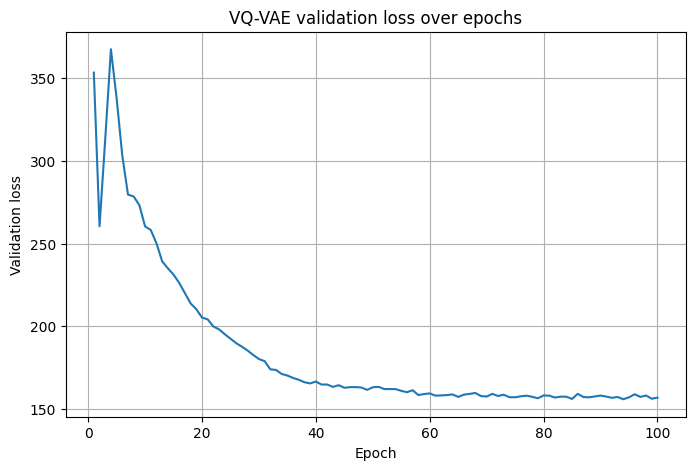

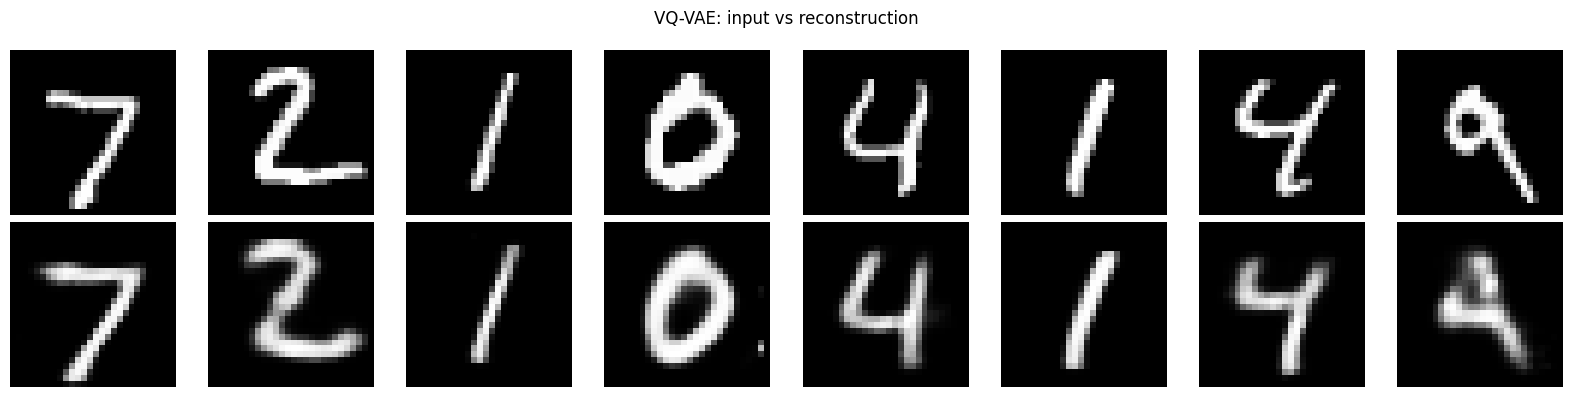

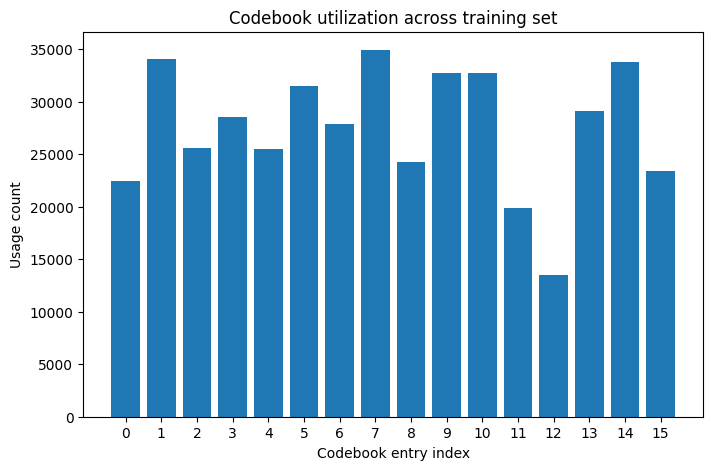

In [ ]:

plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(nll_vqvae) + 1), nll_vqvae)
plt.xlabel('Epoch')
plt.ylabel('Validation loss')
plt.title('VQ-VAE validation loss over epochs')
plt.grid(True)
plt.show()
vqvae.eval()

test_batch, _ = next(iter(test_loader))

with torch.no_grad():
    z_e = vqvae.encoder(test_batch)
    z_q, indices, vq_loss = vqvae.quantizer(z_e)
    recon_batch = vqvae.decoder(z_q)

num_images = 8
plt.figure(figsize=(2 * num_images, 4))

for i in range(num_images):
    # original
    plt.subplot(2, num_images, i + 1)
    plt.imshow(test_batch[i].reshape(28, 28).cpu().numpy(), cmap='gray')
    plt.axis('off')
    if i == 0:
        plt.ylabel('Original', fontsize=12)

    # reconstruction
    plt.subplot(2, num_images, num_images + i + 1)
    plt.imshow(recon_batch[i].reshape(28, 28).cpu().numpy(), cmap='gray')
    plt.axis('off')
    if i == 0:
        plt.ylabel('Reconstruction', fontsize=12)

plt.suptitle('VQ-VAE: input vs reconstruction')
plt.tight_layout()
plt.show()

vqvae.eval()

all_indices = []

with torch.no_grad():
    for batch, _ in training_loader:
        indices = vqvae.encode_indices(batch)   # shape: (B, L)
        all_indices.append(indices.reshape(-1).cpu())

all_indices = torch.cat(all_indices, dim=0).numpy()

counts = np.bincount(all_indices, minlength=K)

plt.figure(figsize=(8, 5))
plt.bar(np.arange(K), counts)
plt.xlabel('Codebook entry index')
plt.ylabel('Usage count')
plt.title('Codebook utilization across training set')
plt.xticks(np.arange(K))
plt.show()

## Part (c): Autoregressive prior over the latent space

In [8]:
class CausalConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation, A=False):
        super(CausalConv1d, self).__init__()
        self.kernel_size = kernel_size
        self.dilation = dilation
        self.A = A
        self.padding = (kernel_size - 1) * dilation + A * 1

        self.conv1d = torch.nn.Conv1d(in_channels,
                                      out_channels,
                                      kernel_size,
                                      stride=1,
                                      padding=0,
                                      dilation=dilation,
                                      bias=True)

    def forward(self, x):
        x = torch.nn.functional.pad(x, (self.padding, 0))
        conv1d_out = self.conv1d(x)
        if self.A:
            return conv1d_out[:, :, :-1]
        else:
            return conv1d_out


class ARPrior(nn.Module):
    def __init__(self, net, num_latents, K):
        super(ARPrior, self).__init__()
        self.net = net      # causal convolutional network
        self.num_latents = num_latents    # length of the discrete latent sequence (L)
        self.K = K          # codebook size (number of possible values per position)
        self.EPS = 1.e-5

    def forward(self, indices, reduction='avg'):
        if reduction == 'avg':
            return -(self.log_prob(indices).mean())
        elif reduction == 'sum':
            return -(self.log_prob(indices).sum())
        else:
            raise ValueError('reduction could be either `avg` or `sum`.')

    def log_prob(self, indices):
        p = self.f(indices)
        indices_one_hot = F.one_hot(indices.long(), num_classes=self.K).float()
        log_p = indices_one_hot * torch.log(torch.clamp(p, self.EPS, 1. - self.EPS))
        log_p = torch.sum(log_p, dim=-1).sum(-1)
        return log_p

    def f(self, indices):
        x = indices.float().unsqueeze(1)
        h = self.net(x)
        h = h.permute(0, 2, 1)
        return torch.softmax(h, dim=-1)

    def sample(self, batch_size):
        indices = torch.zeros((batch_size, self.num_latents), dtype=torch.long)
        for l in range(self.num_latents):
            p = self.f(indices)
            indices[:, l] = torch.multinomial(p[:, l, :], num_samples=1).squeeze(1)
        return indices

In [ ]:
def evaluation_ar_prior(test_loader, vqvae, ar_prior):
    ar_prior.eval()
    loss = 0.
    N = 0.
    for i, (test_batch, _) in enumerate(test_loader):
        indices = vqvae.encode_indices(test_batch)
        loss_t = ar_prior.forward(indices, reduction='sum')
        loss = loss + loss_t.item()
        N = N + test_batch.shape[0]
    loss = loss / N
    return loss


def training_ar_prior(name, num_epochs, vqvae, ar_prior, optimizer, training_loader, val_loader):
    nll_val = []

    for ep in range(num_epochs):
        ar_prior.train()
        for i, (batch, _) in enumerate(training_loader):
            with torch.no_grad():
                indices= vqvae.encode_indices(batch)

            loss= ar_prior.forward(indices)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        val_loss = evaluation_ar_prior(val_loader, vqvae, ar_prior)
        nll_val.append(val_loss)
        print(f'Epoch: {ep}, val nll={val_loss:.4f}')

        ar_prior.eval()
        with torch.no_grad():
            sampled_indicies = ar_prior.sample(batch_size=8)
            samples = vqvae.decode_indices(sampled_indicies)
    return np.asarray(nll_val)

## Part (d): Autoregressive prior initialization, hyperparameters and training

In [10]:
for p in vqvae.parameters():
    p.requires_grad = False
vqvae.eval()

arm_hdim = 128    # hidden layer dimensionality for AR prior
kernel = 3        # causal conv kernel size
lr_arm = 1e-3
num_epochs_arm = 150

prior_net = nn.Sequential(
    CausalConv1d(in_channels=1, out_channels=arm_hdim, dilation=1, kernel_size=kernel, A=True),
    nn.LeakyReLU(),
    CausalConv1d(in_channels=arm_hdim, out_channels=arm_hdim, dilation=1, kernel_size=kernel, A=False),
    nn.LeakyReLU(),
    CausalConv1d(in_channels=arm_hdim, out_channels=arm_hdim, dilation=1, kernel_size=kernel, A=False),
    nn.LeakyReLU(),
    CausalConv1d(in_channels=arm_hdim, out_channels=K, dilation=1, kernel_size=kernel, A=False)
)

ar_prior = ARPrior(prior_net, num_latents=num_latents, K=K)

optimizer_arm = torch.optim.Adam([p for p in ar_prior.parameters() if p.requires_grad == True], lr=lr_arm)

nll_prior = training_ar_prior(name=result_dir + name, num_epochs=num_epochs_arm, vqvae=vqvae,
                              ar_prior=ar_prior, optimizer=optimizer_arm,
                              training_loader=training_loader, val_loader=val_loader)

Epoch: 0, val nll=21.3733
Epoch: 1, val nll=21.1310
Epoch: 2, val nll=21.0254
Epoch: 3, val nll=20.9210
Epoch: 4, val nll=20.8526
Epoch: 5, val nll=20.7448
Epoch: 6, val nll=20.7174
Epoch: 7, val nll=20.6594
Epoch: 8, val nll=20.6393
Epoch: 9, val nll=20.6054
Epoch: 10, val nll=20.5719
Epoch: 11, val nll=20.5441
Epoch: 12, val nll=20.5388
Epoch: 13, val nll=20.5353
Epoch: 14, val nll=20.4979
Epoch: 15, val nll=20.4662
Epoch: 16, val nll=20.4744
Epoch: 17, val nll=20.4567
Epoch: 18, val nll=20.4168
Epoch: 19, val nll=20.4008
Epoch: 20, val nll=20.3892
Epoch: 21, val nll=20.3702
Epoch: 22, val nll=20.3818
Epoch: 23, val nll=20.3713
Epoch: 24, val nll=20.3553
Epoch: 25, val nll=20.3383
Epoch: 26, val nll=20.3384
Epoch: 27, val nll=20.3215
Epoch: 28, val nll=20.3211
Epoch: 29, val nll=20.3158
Epoch: 30, val nll=20.3159
Epoch: 31, val nll=20.2881
Epoch: 32, val nll=20.2799
Epoch: 33, val nll=20.2770
Epoch: 34, val nll=20.2921
Epoch: 35, val nll=20.2803
Epoch: 36, val nll=20.3073
Epoch: 37, 

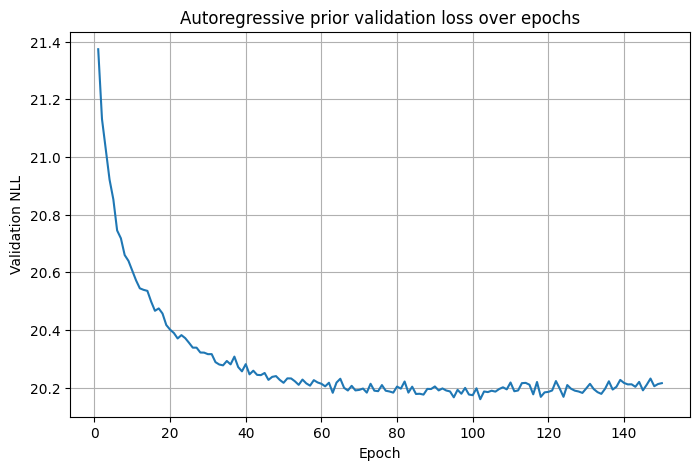

In [12]:
# TODO: Visualize autoregressive prior model training process
# ...
# ...

plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(nll_prior) + 1), nll_prior)
plt.xlabel('Epoch')
plt.ylabel('Validation NLL')
plt.title('Autoregressive prior validation loss over epochs')
plt.grid(True)
plt.show()

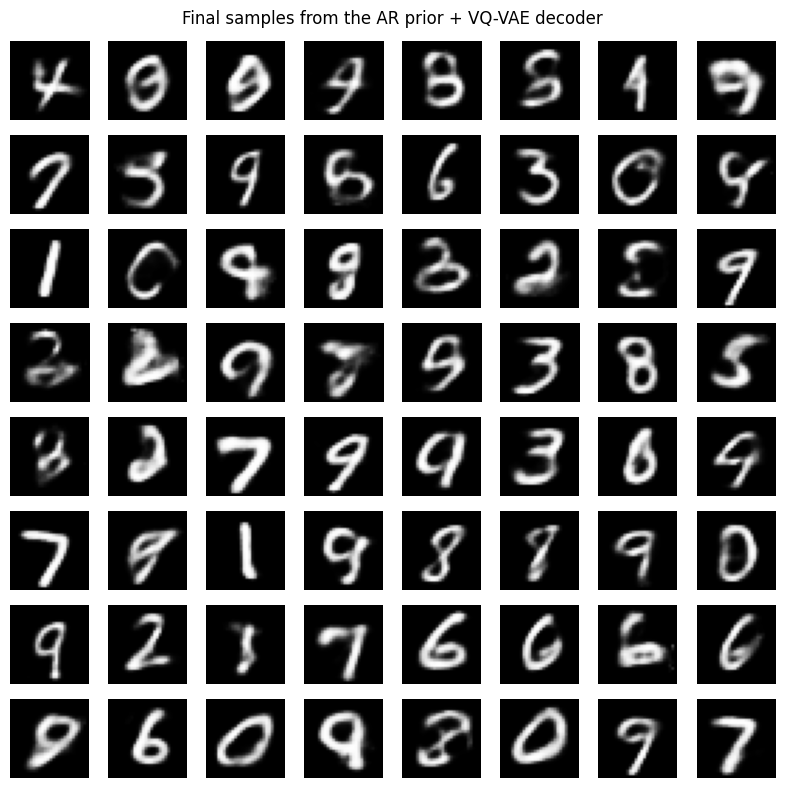

In [13]:
# TODO: Generate final samples from the full model.
# Sample index sequences from the AR prior, then decode with the frozen VQ-VAE decoder.
# ...
# ...
ar_prior.eval()
with torch.no_grad():
    sampled_indices = ar_prior.sample(batch_size=64)
    final_samples = vqvae.decode_indices(sampled_indices)


# TODO: Visualize the final samples from the full model.

plt.figure(figsize=(8, 8))
for i in range(64):
    plt.subplot(8, 8, i + 1)
    plt.imshow(final_samples[i].reshape(28, 28).cpu().numpy(), cmap='gray')
    plt.axis('off')
plt.suptitle('Final samples from the AR prior + VQ-VAE decoder')
plt.tight_layout()
plt.show()